In [13]:
%load_ext autoreload
%autoreload 2

import random
import sys
from pathlib import Path

# Paths come from path_config.yaml; edit that file's current_workstation to switch machines.
from path_config import PMOF_CODE_DIR, DATA_BASE_DIR

if not PMOF_CODE_DIR.is_dir():
    raise FileNotFoundError(f"PMOF code directory not found: {PMOF_CODE_DIR}")

sys.path.insert(0, str(PMOF_CODE_DIR))

from ultralytics import YOLO

from src.data import imgid_to_annpath, imgid_to_imgpath, read_annotation, recordid_to_imageids
from src.visualization import VIZ_PARAMS, results_to_frames

from functools import lru_cache


#plotting
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
@lru_cache(maxsize=None)
def _load_model(model_path: str) -> YOLO:
    """Load and cache a YOLO model so repeated calls reuse the same instance."""
    return YOLO(model_path)


def get_gt_info(img_id):
    """Return the ground-truth alert flag and person annotations (bbox + action) for img_id."""
    annpath = imgid_to_annpath(img_id)
    anns = read_annotation(annpath, img_id)
    person_anns = [ann for ann in anns if ann.category_name == "person"]
    gt_annotation = [{"bbox": ann.bbox, "action": ann.action} for ann in person_anns]
    gt_alert = 1 if any(ann.action != 'seated' for ann in person_anns) else 0
    return gt_alert, gt_annotation


def get_cls_prediction(model_path, frame, conf_threshold=None):
    """Return (alert, confidence) for the cls model; a low-confidence prediction is treated as no alert."""
    model = _load_model(model_path)
    results = model(frame)

    for result in results:
        top1 = result.probs.top1  # top predicted class ID
        top1_conf = result.probs.top1conf.item()  # top prediction confidence

    alert = 0 if conf_threshold is not None and top1_conf < conf_threshold else top1
    return alert, top1_conf


def get_obb_prediction(model_path, frame, conf_threshold=None):
    """Return (alert, detections, results) for the obb model.

    detections is a list of {"bbox": xyxyxyxy polygon, "class": name, "conf": score}, already
    filtered by conf_threshold. results is the raw ultralytics inference output, cached so later
    visualization can reuse it instead of re-running the model.
    """
    model = _load_model(model_path)
    results = model(frame)

    detections = []
    for result in results:
        names = [result.names[cls.item()] for cls in result.obb.cls.int()]  # class name of each box
        confs = result.obb.conf  # confidence score of each box
        polygons = result.obb.xyxyxyxy  # polygon format with 4-points
        for name, conf, polygon in zip(names, confs, polygons):
            conf = conf.item()
            if conf_threshold is not None and conf < conf_threshold:
                continue
            detections.append({"bbox": polygon.tolist(), "class": name, "conf": conf})

    alert = 1 if any(detection["class"] != 'seated' for detection in detections) else 0
    return alert, detections, results


def classify_outcome(gt_alert, pred_alert):
    """Classify a prediction against ground truth as tp/tn/fp/fn."""
    if gt_alert == 0 and pred_alert == 0:
        return 'tn'
    if gt_alert == 1 and pred_alert == 1:
        return 'tp'
    if gt_alert == 0 and pred_alert == 1:
        return 'fp'
    return 'fn'


def evaluate_frame(img_id, model_paths, conf_thresholds=None):
    """Run both models on img_id and return one result row as a dict."""
    conf_thresholds = conf_thresholds or {}
    frame = Path(imgid_to_imgpath(img_id))

    gt_alert, gt_annotation = get_gt_info(img_id)
    cls_alert, cls_conf = get_cls_prediction(model_paths['cls'], frame, conf_thresholds.get('cls'))
    obb_alert, obb_detections, obb_results = get_obb_prediction(model_paths['obb'], frame, conf_thresholds.get('obb'))

    return {
        "frame_id": img_id,
        "gt_alert": gt_alert,
        "gt_annotation": gt_annotation,
        "cls_alert": cls_alert,
        "cls_conf": cls_conf,
        "obb_alert": obb_alert,
        "obb_detections": obb_detections,
        "obb_results": obb_results,
        "cls_eval": classify_outcome(gt_alert, cls_alert),
        "obb_eval": classify_outcome(gt_alert, obb_alert),
    }



# Inference of Models on Validation Set

In [30]:
val_record_ids = ["rec29", "rec30"]

model_paths = {
    'cls': './runs/classify/train/weights/best.pt',
    'obb': './runs/obb/obb2/weights/best.pt',
}

# set either/both to None to disable confidence filtering for that model
conf_thresholds = {'cls': None, 'obb': None}

N_EVAL_FRAMES = 30

test_imgids = [
    img_id
    for rec_id in val_record_ids
    for img_id in recordid_to_imageids(rec_id)
]
random.shuffle(test_imgids)
evaluated_img_ids = test_imgids[:N_EVAL_FRAMES]

frame_results = pd.DataFrame(
    evaluate_frame(img_id, model_paths, conf_thresholds) for img_id in evaluated_img_ids
)
frame_results.head()



image 1/1 /home/stella/computer_vision/PMOF/images/rec30/rec30_001535.png: 320x320 other 0.96, seated 0.04, 2.1ms
Speed: 14.8ms preprocess, 2.1ms inference, 0.0ms postprocess per image at shape (1, 3, 320, 320)

image 1/1 /home/stella/computer_vision/PMOF/images/rec30/rec30_001535.png: 320x320 1 seated, 3.3ms
Speed: 0.5ms preprocess, 3.3ms inference, 0.1ms postprocess per image at shape (1, 3, 320, 320)

image 1/1 /home/stella/computer_vision/PMOF/images/rec30/rec30_001798.png: 320x320 other 0.99, seated 0.01, 1.5ms
Speed: 11.2ms preprocess, 1.5ms inference, 0.0ms postprocess per image at shape (1, 3, 320, 320)

image 1/1 /home/stella/computer_vision/PMOF/images/rec30/rec30_001798.png: 320x320 (no detections), 3.6ms
Speed: 0.5ms preprocess, 3.6ms inference, 0.1ms postprocess per image at shape (1, 3, 320, 320)

image 1/1 /home/stella/computer_vision/PMOF/images/rec30/rec30_002057.png: 320x320 other 0.96, seated 0.04, 1.5ms
Speed: 10.1ms preprocess, 1.5ms inference, 0.0ms postprocess p

,frame_id,gt_alert,gt_annotation,cls_alert,cls_conf,obb_alert,obb_detections,obb_results,cls_eval,obb_eval
0,rec30_001535,0,"[{'bbox': [793.98, 223.57, 456.61, 741.71], 'a...",0,0.958561,0,"[{'bbox': [[1204.3851318359375, 996.9979248046...",[((ultralytics.engine.results.Results object w...,tn,tn
1,rec30_001798,1,"[{'bbox': [702.19, 815.43, 343.55, 504.16], 'a...",0,0.990537,0,[],[()],fn,fn
2,rec30_002057,0,"[{'bbox': [763.17, 326.2, 415.04, 579.59], 'ac...",0,0.964372,0,"[{'bbox': [[1209.780517578125, 953.6015625], [...",[((ultralytics.engine.results.Results object w...,tn,tn
3,rec29_000931,1,"[{'bbox': [770.2, 707.29, 513.18, 577.54], 'ac...",0,0.894312,1,"[{'bbox': [[1047.625, 1691.5203857421875], [10...",[((ultralytics.engine.results.Results object w...,fn,tp
4,rec29_001442,1,"[{'bbox': [741.06, 807.14, 565.21, 412.88], 'a...",0,0.961450,1,"[{'bbox': [[1052.1689453125, 857.7362670898438...",[((ultralytics.engine.results.Results object w...,fn,tp


In [31]:
frame_results

,frame_id,gt_alert,gt_annotation,cls_alert,cls_conf,obb_alert,obb_detections,obb_results,cls_eval,obb_eval
0,rec30_001535,0,"[{'bbox': [793.98, 223.57, 456.61, 741.71], 'a...",0,0.958561,0,"[{'bbox': [[1204.3851318359375, 996.9979248046...",[((ultralytics.engine.results.Results object w...,tn,tn
1,rec30_001798,1,"[{'bbox': [702.19, 815.43, 343.55, 504.16], 'a...",0,0.990537,0,[],[()],fn,fn
2,rec30_002057,0,"[{'bbox': [763.17, 326.2, 415.04, 579.59], 'ac...",0,0.964372,0,"[{'bbox': [[1209.780517578125, 953.6015625], [...",[((ultralytics.engine.results.Results object w...,tn,tn
3,rec29_000931,1,"[{'bbox': [770.2, 707.29, 513.18, 577.54], 'ac...",0,0.894312,1,"[{'bbox': [[1047.625, 1691.5203857421875], [10...",[((ultralytics.engine.results.Results object w...,fn,tp
4,rec29_001442,1,"[{'bbox': [741.06, 807.14, 565.21, 412.88], 'a...",0,0.961450,1,"[{'bbox': [[1052.1689453125, 857.7362670898438...",[((ultralytics.engine.results.Results object w...,fn,tp
5,rec29_000872,0,"[{'bbox': [627.3, 294.9, 490.9, 604.6], 'actio...",0,0.622773,0,"[{'bbox': [[1120.385498046875, 888.2890625], [...",[((ultralytics.engine.results.Results object w...,tn,tn
6,rec30_001617,0,"[{'bbox': [732.54, 300.87, 491.8, 664.33], 'ac...",0,0.974307,0,"[{'bbox': [[1188.6971435546875, 979.1362915039...",[((ultralytics.engine.results.Results object w...,tn,tn
7,rec29_000870,0,"[{'bbox': [627.3, 289.85, 496.55, 623.75], 'ac...",0,0.510472,0,"[{'bbox': [[1125.751708984375, 890.89044189453...",[((ultralytics.engine.results.Results object w...,tn,tn
8,rec29_001252,1,"[{'bbox': [913.07, 627.49, 633.85, 947.65], 'a...",0,0.974261,1,"[{'bbox': [[1262.160400390625, 1775.1710205078...",[((ultralytics.engine.results.Results object w...,fn,tp
9,rec30_001879,0,"[{'bbox': [725.96, 204.88, 398.76, 864.99], 'a...",0,0.666324,0,"[{'bbox': [[1116.08447265625, 1053.55688476562...",[((ultralytics.engine.results.Results object w...,tn,tn


# Alert Results

In [32]:
for model_type in model_paths:
    print(model_type)
    counts = frame_results[f"{model_type}_eval"].value_counts()
    for outcome in ['tn', 'tp', 'fp', 'fn']:
        print(f"  {outcome}: {counts.get(outcome, 0)}")


cls
  tn: 13
  tp: 0
  fp: 1
  fn: 16
obb
  tn: 13
  tp: 14
  fp: 1
  fn: 2


In [33]:
import itertools

for model_type in model_paths:
    eval_column = f"{model_type}_eval"
    counts = frame_results[eval_column].value_counts()

    # sanity check: tn + tp + fp + fn should equal the number of evaluated frames
    total_categorized = int(counts.sum())
    assert total_categorized == len(frame_results), (
        f"{model_type}: tn+tp+fp+fn ({total_categorized}) != evaluated frames ({len(frame_results)})"
    )

    # sanity check: a frame can't belong to more than one outcome for the same model
    id_sets = {
        outcome: set(frame_results.loc[frame_results[eval_column] == outcome, "frame_id"])
        for outcome in ['tn', 'tp', 'fp', 'fn']
    }
    for category_a, category_b in itertools.combinations(id_sets, 2):
        overlap = id_sets[category_a] & id_sets[category_b]
        assert not overlap, f"{model_type}: overlap between {category_a} and {category_b}: {overlap}"

print("Sanity checks passed: counts sum to evaluated frames and categories don't overlap.")



Sanity checks passed: counts sum to evaluated frames and categories don't overlap.


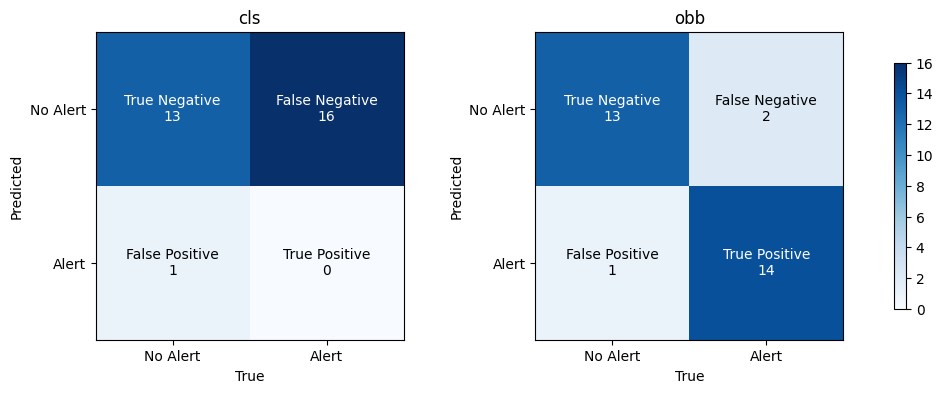

Ground truth: 14 no alert, 16 alert


In [34]:
CONFUSION_CELL_LABELS = np.array([
    ['True Negative', 'False Negative'],
    ['False Positive', 'True Positive'],
])


def build_confusion_matrix(eval_column):
    counts = frame_results[eval_column].value_counts()
    return np.array([
        [counts.get('tn', 0), counts.get('fn', 0)],
        [counts.get('fp', 0), counts.get('tp', 0)],
    ])


def plot_confusion_matrix(ax, matrix, title, vmax):
    """Draw a 2x2 (predicted vs true) alert confusion matrix on ax."""
    image = ax.imshow(matrix, cmap='Blues', vmin=0, vmax=vmax)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['No Alert', 'Alert'])
    ax.set_yticklabels(['No Alert', 'Alert'])
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.set_title(title)

    threshold = vmax / 2
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, f"{CONFUSION_CELL_LABELS[i, j]}\n{matrix[i, j]}",
                ha='center', va='center',
                color='white' if matrix[i, j] > threshold else 'black',
            )
    return image


matrices = {model_type: build_confusion_matrix(f"{model_type}_eval") for model_type in model_paths}
vmax = max(matrix.max() for matrix in matrices.values())

fig, axes = plt.subplots(1, len(matrices), figsize=(6.5 * len(matrices), 4))
axes = np.atleast_1d(axes)
for ax, (model_type, matrix) in zip(axes, matrices.items()):
    image = plot_confusion_matrix(ax, matrix, model_type, vmax)

fig.colorbar(image, ax=axes, shrink=0.8)
plt.show()

gt_counts = frame_results['gt_alert'].value_counts()
print(f"Ground truth: {gt_counts.get(0, 0)} no alert, {gt_counts.get(1, 0)} alert")


In [35]:
# Calculate precision, recall, and F1 score for each model
def calculate_metrics(eval_column):
    counts = frame_results[eval_column].value_counts()
    tp = counts.get('tp', 0)
    fp = counts.get('fp', 0)
    fn = counts.get('fn', 0)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1_score

calculate_metrics_results = {model_type: calculate_metrics(f"{model_type}_eval") for model_type in model_paths}
for model_type, (precision, recall, f1_score) in calculate_metrics_results.items():
    print(f"{model_type} - Precision: {precision:.2f}, Recall: {recall:.2f}, F1 Score: {f1_score:.2f}")


cls - Precision: 0.00, Recall: 0.00, F1 Score: 0.00
obb - Precision: 0.93, Recall: 0.88, F1 Score: 0.90


# Failure Case Analysis

In [36]:
frame_results

,frame_id,gt_alert,gt_annotation,cls_alert,cls_conf,obb_alert,obb_detections,obb_results,cls_eval,obb_eval
0,rec30_001535,0,"[{'bbox': [793.98, 223.57, 456.61, 741.71], 'a...",0,0.958561,0,"[{'bbox': [[1204.3851318359375, 996.9979248046...",[((ultralytics.engine.results.Results object w...,tn,tn
1,rec30_001798,1,"[{'bbox': [702.19, 815.43, 343.55, 504.16], 'a...",0,0.990537,0,[],[()],fn,fn
2,rec30_002057,0,"[{'bbox': [763.17, 326.2, 415.04, 579.59], 'ac...",0,0.964372,0,"[{'bbox': [[1209.780517578125, 953.6015625], [...",[((ultralytics.engine.results.Results object w...,tn,tn
3,rec29_000931,1,"[{'bbox': [770.2, 707.29, 513.18, 577.54], 'ac...",0,0.894312,1,"[{'bbox': [[1047.625, 1691.5203857421875], [10...",[((ultralytics.engine.results.Results object w...,fn,tp
4,rec29_001442,1,"[{'bbox': [741.06, 807.14, 565.21, 412.88], 'a...",0,0.961450,1,"[{'bbox': [[1052.1689453125, 857.7362670898438...",[((ultralytics.engine.results.Results object w...,fn,tp
5,rec29_000872,0,"[{'bbox': [627.3, 294.9, 490.9, 604.6], 'actio...",0,0.622773,0,"[{'bbox': [[1120.385498046875, 888.2890625], [...",[((ultralytics.engine.results.Results object w...,tn,tn
6,rec30_001617,0,"[{'bbox': [732.54, 300.87, 491.8, 664.33], 'ac...",0,0.974307,0,"[{'bbox': [[1188.6971435546875, 979.1362915039...",[((ultralytics.engine.results.Results object w...,tn,tn
7,rec29_000870,0,"[{'bbox': [627.3, 289.85, 496.55, 623.75], 'ac...",0,0.510472,0,"[{'bbox': [[1125.751708984375, 890.89044189453...",[((ultralytics.engine.results.Results object w...,tn,tn
8,rec29_001252,1,"[{'bbox': [913.07, 627.49, 633.85, 947.65], 'a...",0,0.974261,1,"[{'bbox': [[1262.160400390625, 1775.1710205078...",[((ultralytics.engine.results.Results object w...,fn,tp
9,rec30_001879,0,"[{'bbox': [725.96, 204.88, 398.76, 864.99], 'a...",0,0.666324,0,"[{'bbox': [[1116.08447265625, 1053.55688476562...",[((ultralytics.engine.results.Results object w...,tn,tn


In [37]:
OUTCOME_TITLES = {
    'tp': 'True Positives',
    'tn': 'True Negatives',
    'fp': 'False Positives',
    'fn': 'False Negatives',
}


def sample_frame_ids(model_type, outcome, n_samples, seed=1):
    """Randomly sample up to n_samples frame ids for a given model_type/outcome pair."""
    matching = frame_results.loc[frame_results[f"{model_type}_eval"] == outcome, "frame_id"]
    return matching.sample(n=min(n_samples, len(matching)), random_state=seed).tolist()


def render_obb_frame(img_id, model_path, display_gt=True):
    """Render a frame with predicted obb boxes, optionally with GT boxes (colored by action) overlaid.

    Reuses the obb inference results cached in frame_results (evaluate_frame) instead of re-running the model.
    """
    cached_results = frame_results.loc[frame_results['frame_id'] == img_id, 'obb_results']
    if not cached_results.empty and cached_results.iloc[0] is not None:
        results = cached_results.iloc[0]
    else:
        frame_path = Path(imgid_to_imgpath(img_id))
        model = _load_model(model_path)
        results = model(frame_path)

    # pmof-code helper draws predicted obb boxes plus GT boxes (colored by action) onto the frame
    # gt_person_only restricts GT to the "person" category (drops bag/clothing)
    frames = results_to_frames(results, data_base_dir=DATA_BASE_DIR, actions=True, gt_person_only=True, display_gt=display_gt)
    return frames[img_id]


ALERT_COLORS = {0: 'tab:green', 1: 'tab:pink'} #0 no alert, 1 alert
ALERT_LABELS = {0: 'No Alert', 1: 'Alert'}
# (gt_alert, pred_alert) for each outcome, matching classify_outcome
OUTCOME_ALERTS = {'tn': (0, 0), 'tp': (1, 1), 'fp': (0, 1), 'fn': (1, 0)}


def _draw_alert_border(ax, color, inset, linestyle):
    """Draw a rectangle border in axes coordinates, inset fractionally from the edge."""
    border = Rectangle(
        (inset, inset), 1 - 2 * inset, 1 - 2 * inset,
        transform=ax.transAxes, fill=False, clip_on=False,
        edgecolor=color, linewidth=3, linestyle=linestyle,
    )
    ax.add_patch(border)


def plot_collage(i, model_type, outcome, seed=1, display_gt=True):
    """Plot an i x i collage of sampled frames for model_type/outcome, titled above the grid.

    Each frame gets a solid outer border for the GT alert and a dashed, inset border for the
    predicted alert (both tab:green = no alert, tab:red = alert).
    """
    sample_ids = sample_frame_ids(model_type, outcome, i * i, seed=seed)
    if not sample_ids:
        print(f"No samples found for {model_type}/{outcome}.")
        return

    fig, axes = plt.subplots(i, i, figsize=(3 * i, 3 * i))
    axes = np.atleast_2d(axes)
    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    for ax, img_id in zip(axes.flat, sample_ids):
        if model_type == 'obb':
            frame = render_obb_frame(img_id, model_paths['obb'], display_gt=display_gt)
        else:
            frame = plt.imread(imgid_to_imgpath(img_id))
        ax.imshow(frame)
        ax.set_title(img_id, fontsize=8)

        row = frame_results.loc[frame_results['frame_id'] == img_id].iloc[0]
        _draw_alert_border(ax, ALERT_COLORS[row['gt_alert']], inset=0.0, linestyle='solid')
        _draw_alert_border(ax, ALERT_COLORS[row[f'{model_type}_alert']], inset=0.02, linestyle='dashed')

    gt_alert, pred_alert = OUTCOME_ALERTS[outcome]
    legend_handles = [
        Line2D([0], [0], color=ALERT_COLORS[gt_alert], lw=2, linestyle='solid', label=f'GT: {ALERT_LABELS[gt_alert]}'),
        Line2D([0], [0], color=ALERT_COLORS[pred_alert], lw=2, linestyle='dashed', label=f'Predicted: {ALERT_LABELS[pred_alert]}'),
    ]
    fig.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.99, 0.99), fontsize=8)

    fig.suptitle(f"{model_type.upper()} \u2013 {OUTCOME_TITLES[outcome]}")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



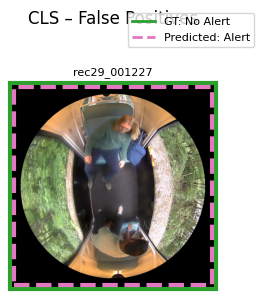

In [38]:
plot_collage(1, 'cls', 'fp')

Visualizing results: 100%|██████████| 1/1 [00:00<00:00,  4.02it/s]


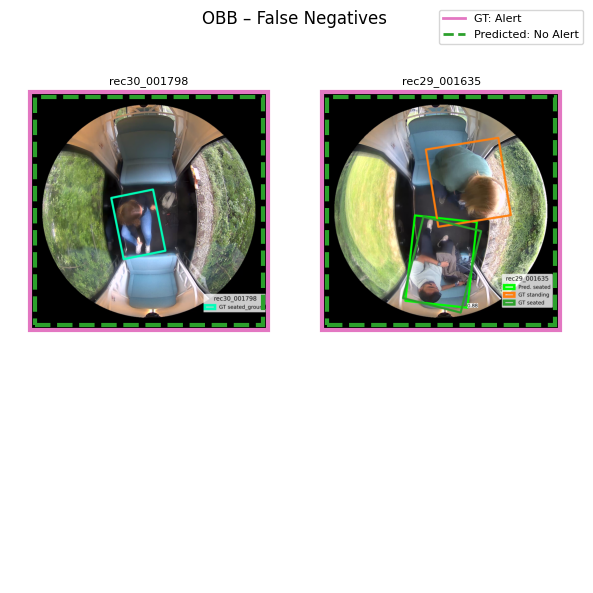

In [44]:
plot_collage(2, 'obb', 'fn', display_gt=True)

In [43]:
frame_results[frame_results.obb_eval == 'fp']


,frame_id,gt_alert,gt_annotation,cls_alert,cls_conf,obb_alert,obb_detections,obb_results,cls_eval,obb_eval
24,rec29_001227,0,"[{'bbox': [697.93, 262.13, 459.67, 749.0], 'ac...",1,0.811321,1,"[{'bbox': [[1125.055908203125, 1040.0209960937...",[((ultralytics.engine.results.Results object w...,fp,fp
